# OptiCore Quickstart

This notebook covers the core features of OptiCore in 5 minutes:
1. Price a European option
2. Solve for implied volatility
3. Compute all Greeks
4. Vectorized batch pricing
5. Visualize Greeks profiles and payoff diagrams

In [1]:
import opticore as oc
import numpy as np

print(f"OptiCore version: {oc.__version__}")

OptiCore version: 0.2.0


## 1. Price a European Call

Using Black-Scholes-Merton with:
- Spot = $100, Strike = $105
- 6 months to expiry, 5% risk-free rate
- 20% annualized volatility

In [2]:
call_price = oc.price(spot=100, strike=105, expiry=0.5, rate=0.05, vol=0.20, kind="call")
put_price  = oc.price(spot=100, strike=105, expiry=0.5, rate=0.05, vol=0.20, kind="put")

print(f"Call price: ${call_price:.4f}")
print(f"Put  price: ${put_price:.4f}")

# Verify put-call parity: C - P = S - K*exp(-rT)
parity_lhs = call_price - put_price
parity_rhs = 100 - 105 * np.exp(-0.05 * 0.5)
print(f"\nPut-call parity check: {parity_lhs:.6f} = {parity_rhs:.6f}")

Call price: $4.5817
Put  price: $6.9892

Put-call parity check: -2.407541 = -2.407541


## 2. Implied Volatility

Given a market price, solve for the volatility that produces it.
Uses Jaeckel's "Let's Be Rational" — full 64-bit precision in 2 iterations.

In [3]:
# Start with a known vol, price it, then solve back
true_vol = 0.25
market_price = oc.price(spot=100, strike=105, expiry=0.5, rate=0.05, vol=true_vol, kind="call")

solved_vol = oc.iv(price=market_price, spot=100, strike=105, expiry=0.5, rate=0.05, kind="call")

print(f"True vol:   {true_vol:.10f}")
print(f"Solved vol: {solved_vol:.10f}")
print(f"Error:      {abs(solved_vol - true_vol):.2e}")

True vol:   0.2500000000
Solved vol: 0.2500000000
Error:      1.39e-16


## 3. Greeks — All at Once

Price + Delta + Gamma + Theta + Vega + Rho in a single pass.

In [4]:
g = oc.greeks(spot=100, strike=105, expiry=0.5, rate=0.05, vol=0.20, kind="call")

print(f"Price: ${g.price:.4f}")
print(f"Delta: {g.delta:.4f}    (position moves ${g.delta:.2f} per $1 spot move)")
print(f"Gamma: {g.gamma:.4f}    (delta changes {g.gamma:.4f} per $1 spot move)")
print(f"Theta: {g.theta:.4f}   (loses ${abs(g.theta):.4f} per day)")
print(f"Vega:  {g.vega:.4f}    (gains ${g.vega:.4f} per 1% vol increase)")
print(f"Rho:   {g.rho:.4f}    (gains ${g.rho:.4f} per 1% rate increase)")

Price: $4.5817
Delta: 0.4612    (position moves $0.46 per $1 spot move)
Gamma: 0.0281    (delta changes 0.0281 per $1 spot move)
Theta: -0.0211   (loses $0.0211 per day)
Vega:  0.2808    (gains $0.2808 per 1% vol increase)
Rho:   0.2077    (gains $0.2077 per 1% rate increase)


## 4. Vectorized — Price an Entire Strike Ladder

In [5]:
strikes = np.arange(80, 121, dtype=float)

# All 41 prices in one call
prices = oc.price(spot=100, strike=strikes, expiry=0.5, rate=0.05, vol=0.20, kind="call")

# Or get a full Greeks table as a DataFrame
df = oc.greeks_table(spot=100, strike=strikes, expiry=0.5, rate=0.05, vol=0.20, kind="call")
df.head(10)

,strike,expiry,price,delta,gamma,theta,vega,rho
0,80.0,0.5,22.174561,0.966026,0.005332,-0.013117,0.053319,0.372140
1,81.0,0.5,21.248569,0.958851,0.006235,-0.013641,0.062351,0.373183
2,82.0,0.5,20.332085,0.950605,0.007222,-0.014194,0.072223,0.373642
3,83.0,0.5,19.426347,0.941213,0.008289,-0.014774,0.082895,0.373475
4,84.0,0.5,18.532645,0.930610,0.009430,-0.015377,0.094304,0.372642
5,85.0,0.5,17.652310,0.918744,0.010637,-0.015996,0.106367,0.371110
6,86.0,0.5,16.786698,0.905571,0.011898,-0.016625,0.118984,0.368852
7,87.0,0.5,15.937173,0.891066,0.013203,-0.017258,0.132034,0.365847
8,88.0,0.5,15.105090,0.875217,0.014538,-0.017886,0.145384,0.362083
9,89.0,0.5,14.291777,0.858029,0.015889,-0.018502,0.158885,0.357556


## 5. Visualization

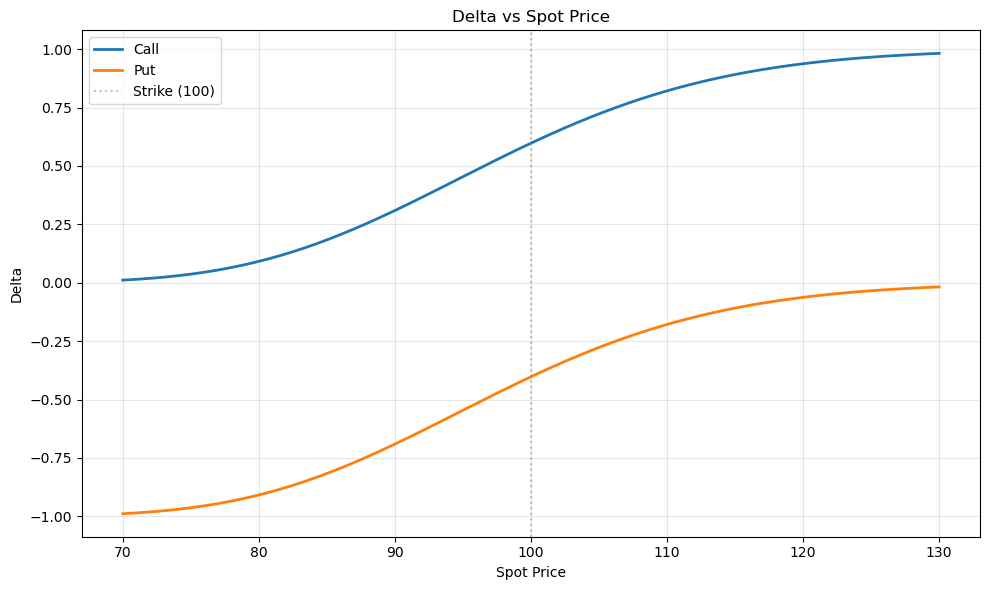

In [6]:
# Greeks profile: how delta changes with spot price
fig = oc.plot.greek(
    "delta", spot_range=(70, 130),
    strike=100, expiry=0.5, rate=0.05, vol=0.20, kind="both"
)

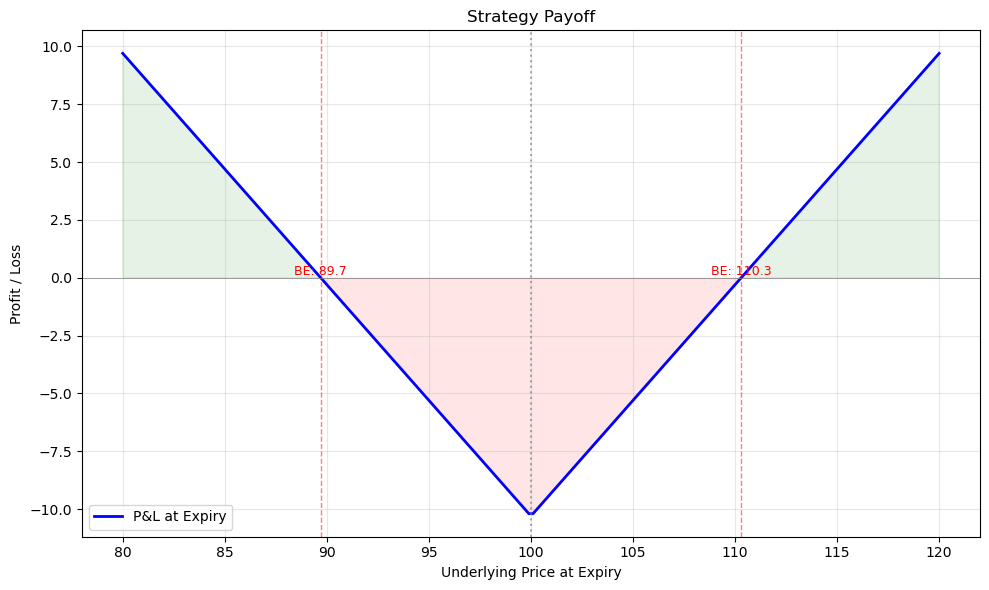

In [7]:
# Payoff diagram: long straddle
fig = oc.plot.payoff([
    oc.Leg("call", strike=100, qty=1, premium=5.50),
    oc.Leg("put",  strike=100, qty=1, premium=4.80),
])

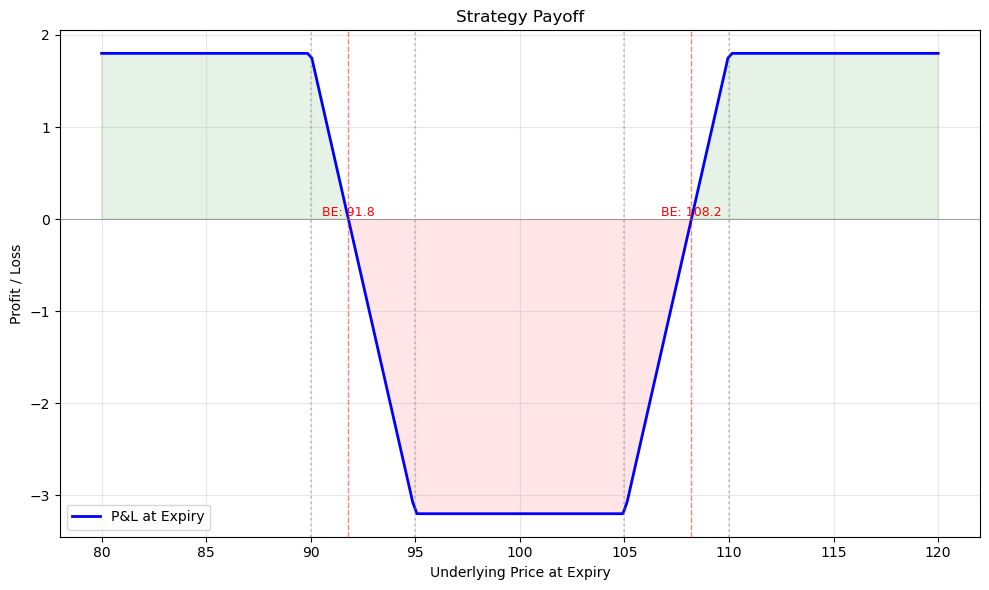

In [8]:
# Payoff diagram: iron condor
fig = oc.plot.payoff([
    oc.Leg("put",  strike=90,  qty=-1, premium=1.50),
    oc.Leg("put",  strike=95,  qty=1,  premium=3.00),
    oc.Leg("call", strike=105, qty=1,  premium=3.50),
    oc.Leg("call", strike=110, qty=-1, premium=1.80),
], spot_range=(80, 120))